In [325]:
# Importing Libraries
import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx,subgraph
import networkx as nx
import pandas as pd
import numpy as np
print("All libraries imported!")

All libraries imported!


In [326]:
# Loading the datasets :
classes=pd.read_csv('/Users/rageshwer/Goal ML/Projects/AML - GNN/data/elliptic_txs_classes.csv')
edge_list=pd.read_csv('/Users/rageshwer/Goal ML/Projects/AML - GNN/data/elliptic_txs_edgelist.csv')
features=pd.read_csv('/Users/rageshwer/Goal ML/Projects/AML - GNN/data/elliptic_txs_features.csv',header=None)

In [327]:
# Checking for duplicates :
print(f"Duplicates in classes df :{classes.duplicated().sum()}")
print(f"Duplicates in features df :{features.duplicated().sum()}")
print(f"Duplicates in edge list df :{edge_list.duplicated().sum()}")
print()
# Checking for missing :
print(f"Missing in classes df :{classes.isna().sum().sum()}")
print(f"Missing in features df :{features.isna().sum().sum()}")
print(f"Missing in edge list df :{edge_list.isna().sum().sum()}")

Duplicates in classes df :0
Duplicates in features df :0
Duplicates in edge list df :0

Missing in classes df :0
Missing in features df :0
Missing in edge list df :0


In [328]:
# The shapes :
print(f"Shape of edge list df :{edge_list.shape}")
print(f"Shape of classes df :{classes.shape}")
print(f"Shape of features df :{features.shape}")

Shape of edge list df :(234355, 2)
Shape of classes df :(203769, 2)
Shape of features df :(203769, 167)


In [329]:
# The features DF :
print(features.head(5))

         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.061584 -0.162112  ...  0.947382  0.673103 -0.979074 -0.978556   
2 -0.113002  -0.061584 -0.162749  ...  0.670883  0.439728 -0.979074 -0.978556   
3  9.782742  12.414558 -0.163645  ... -0.577099 -0.613614  0.241128  0.241406   
4  1.312656  -0.061584 -0.163523  ... -0.511871 -0.400422  0.517257  0.579382   

        161       162       163       164       165       166  
0  0.018279 -0.0

The features DF has first column as "transaction IDs" and second is the "temporal time steps". So, renaming them for convinience.

In [330]:
features.rename(columns={0:'txId',1:'timestep'},inplace=True)

In [331]:
# The classes DF :
print(classes.head(5))
print(classes['class'].value_counts())
print(type(classes['class'][2]))

        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
<class 'str'>


The licit is 2, illicit is 1 and rest nodes are marked 'unknown'. The data type is 'str' and need to be converted into 'int'.

In [332]:
# Converting string labels into int :
class_dict={'1':1,'2':0,'unknown':-1}
classes['class']=classes['class'].map(class_dict)
classes=classes.copy()

In [333]:
# The edge list DF :
print(edge_list.head(5))

       txId1      txId2
0  230425980    5530458
1  232022460  232438397
2  230460314  230459870
3  230333930  230595899
4  232013274  232029206


In [334]:
# The edge matrix contains float values while the features txn ids are int. So this creates mapping mismatch.
# Converting into int:
edge_list['txId1']=edge_list['txId1'].astype(int)
edge_list['txId2']=edge_list['txId2'].astype(int)

In [335]:
# Mapping the transaction Ids into zero indexed continuous integers:
# Creating dictionary:
id_map={raw:idx for idx,raw in enumerate(features['txId'].unique())}

# Mapping:
node_idx_series=features.loc[:,'txId'].map(id_map).rename('node_idx')
features=pd.concat([features,node_idx_series],axis=1)

classes['node_idx']=classes['txId'].map(id_map)
classes=classes.copy()

edge_list['txId1']=edge_list['txId1'].map(id_map)
edge_list['txId2']=edge_list['txId2'].map(id_map)
edge_list=edge_list.copy()

Pandas does not guarantee that the order of rows in features match with the order in classes, so, to create tensors we will first sort them.

In [336]:
# Sorting according to node indexes to match the labels with node features :
features.sort_values(by='node_idx',ascending=True,inplace=True)
classes.sort_values(by='node_idx',ascending=True,inplace=True)

In [337]:
# Preserving the timesteps :
timesteps = torch.tensor(features['timestep'].values,dtype=torch.long)

In [338]:
# Now creating the tensors for the graph:
X=torch.tensor(features.drop(['node_idx','txId','timestep'],axis=1).values,dtype=torch.float32)

edge_index=torch.tensor(edge_list.values,dtype=torch.long).T

y=torch.tensor(classes['class'].values,dtype=torch.long)

In [339]:
graph=Data(x=X,edge_index=edge_index,y=y)
graph.timestep=timesteps

Now masking the nodes for training and validation. The tensors are sorted, so the 0th index node of X, y, timestep and train_mask will correspond to same node. y, timestep and masks(boolean) are 1D tensors.

In [340]:
# Ignoring the -1 (unlabelled)
labelled_masks=(graph.y==0) | (graph.y==1)
graph.train_mask= (graph.timestep<=34) & labelled_masks
graph.test_mask= (graph.timestep>34) & labelled_masks

# We have masked only the labelled nodes from time step 1 to 34 for train and rest for testing. (Only labelled!)  

In [341]:
# Saving the graph
torch.save(graph,'/Users/rageshwer/Goal ML/Projects/AML - GNN/data/graphs/elliptic_graph_processed.pt')

#### Viewing a sub-graph

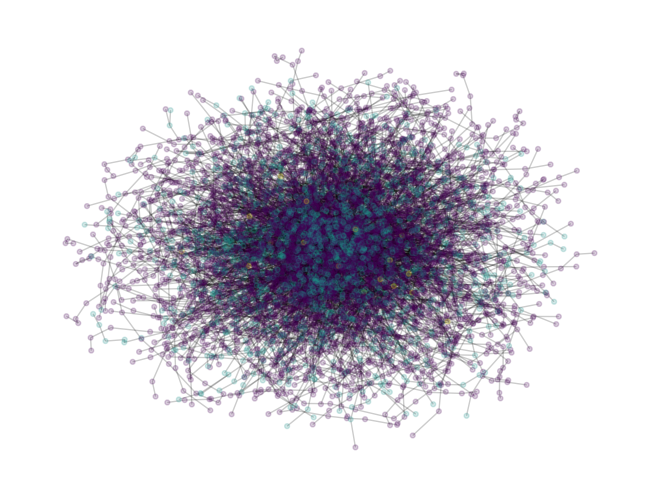

In [342]:
step1=(graph.timestep==1) # Mask for time step 1
step_idx=step1.nonzero(as_tuple=False).view(-1) # Get actual indices of nodes in time step 1
sub_edge_index, _ = subgraph(step_idx, graph.edge_index, relabel_nodes=True)

sub_graph_data = Data(
    x=graph.x[step1],
    edge_index=sub_edge_index,
    y=graph.y[step1]
)

G=to_networkx(sub_graph_data,to_undirected=True)

# Extract largest connected component of subgraph (Giant Connected Component):
components = sorted(nx.connected_components(G), key=len, reverse=True)
gcc_nodes = components[0]
G_gcc = G.subgraph(gcc_nodes)
gcc_colors = [sub_graph_data.y[node].item() for node in G_gcc.nodes()]

# Plotting
pos = nx.spring_layout(G_gcc, seed=42, k=0.15)
nx.draw(G_gcc,pos=pos,node_size=12,node_color=gcc_colors,alpha=0.2)